# ⚙️ BERT & GPT 핵심 알고리즘 구현

In [1]:
import warnings
warnings.filterwarnings('ignore')

import os
os.environ["HF_HUB_DISABLE_SYMLINKS_WARNING"] = "1"

import logging
logging.getLogger("huggingface_hub").setLevel(logging.ERROR)

import transformers
transformers.logging.set_verbosity_error()

import matplotlib.pyplot as plt
if os.name == 'nt':
    plt.rc('font', family='Malgun Gothic') # 윈도우 맑은 고딕
plt.rcParams['axes.unicode_minus'] = False # 마이너스 기호 깨짐 방지

import torch
import torch.nn.functional as F
import numpy as np
import seaborn as sns
import random

## 1. GPT 핵심: Causal Masking (Look-ahead Mask)
GPT와 같은 생성형 모델은 '미래의 단어'를 커닝하지 못하도록 가려야 합니다. 이를 위한 하삼각행렬 마스크를 만들어 봅니다.

Causal Mask Tensor:
 tensor([[1., 0., 0., 0., 0., 0., 0., 0.],
        [1., 1., 0., 0., 0., 0., 0., 0.],
        [1., 1., 1., 0., 0., 0., 0., 0.],
        [1., 1., 1., 1., 0., 0., 0., 0.],
        [1., 1., 1., 1., 1., 0., 0., 0.],
        [1., 1., 1., 1., 1., 1., 0., 0.],
        [1., 1., 1., 1., 1., 1., 1., 0.],
        [1., 1., 1., 1., 1., 1., 1., 1.]])


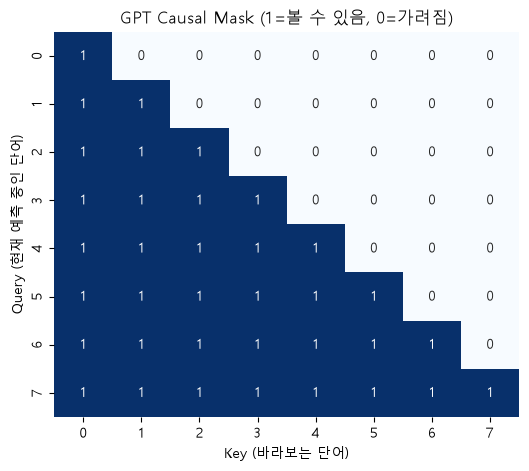

In [2]:
def create_causal_mask(seq_len):
    # torch.tril은 행렬의 대각선을 기준으로 아래쪽(하삼각)은 1, 위쪽은 0으로 만듭니다.
    mask = torch.tril(torch.ones(seq_len, seq_len))
    return mask

seq_len = 8
mask = create_causal_mask(seq_len)

print("Causal Mask Tensor:\n", mask)

# 시각화
plt.figure(figsize=(6, 5))
sns.heatmap(mask.numpy(), annot=True, cmap='Blues', cbar=False)
plt.title("GPT Causal Mask (1=볼 수 있음, 0=가려짐)")
plt.xlabel("Key (바라보는 단어)")
plt.ylabel("Query (현재 예측 중인 단어)")
plt.show()

## 2. GPT 추론 루프: Autoregressive Generation
단방향(Unidirectional) 모델이 다음 단어를 계속해서 예측하여 이어붙이는 기초적인 텍스트 생성 루프입니다.

In [3]:
# 가상의 단어장과 임베딩 (Vocab size: 10)
vocab = ["<PAD>", "I", "love", "machine", "learning", "very", "much", "!", "Hello", "world"]
word2idx = {w: i for i, w in enumerate(vocab)}
idx2word = {i: w for i, w in enumerate(vocab)}

def mock_gpt_forward(input_ids):
    # 실제 GPT 모델 대신, 입력의 가장 마지막 토큰에 의존하여 랜덤하지만 그럴듯한 다음 토큰 확률을 반환하는 가짜 함수
    batch_size, seq_len = input_ids.shape
    logits = torch.randn(batch_size, seq_len, len(vocab))
    # 단순화를 위해 마지막 스텝의 로짓만 추출
    next_token_logits = logits[:, -1, :] 
    return next_token_logits

def generate_text(prompt_tokens, max_new_tokens=5):
    input_ids = torch.tensor([prompt_tokens])
    
    print(f"초기 프롬프트: {' '.join([idx2word[idx] for idx in prompt_tokens])}")
    
    for step in range(max_new_tokens):
        # 1. 모델에 현재까지의 시퀀스 입력
        logits = mock_gpt_forward(input_ids)
        
        # 2. 가장 높은 확률의 다음 토큰 선택 (Greedy Search)
        next_token_id = torch.argmax(logits, dim=-1).item()
        
        # 3. 예측한 토큰을 입력 시퀀스에 이어붙임 (Autoregressive)
        input_ids = torch.cat([input_ids, torch.tensor([[next_token_id]])], dim=1)
        
        print(f"Step {step+1} 생성 토큰: {idx2word[next_token_id]}")
        
    generated_text = ' '.join([idx2word[idx] for idx in input_ids[0].tolist()])
    return generated_text

prompt = [word2idx["I"], word2idx["love"]]
final_text = generate_text(prompt, max_new_tokens=4)
print(f"\n최종 생성 문장: {final_text}")

초기 프롬프트: I love
Step 1 생성 토큰: !
Step 2 생성 토큰: much
Step 3 생성 토큰: much
Step 4 생성 토큰: very

최종 생성 문장: I love ! much much very


## 3. BERT 핵심: Masked Language Modeling (MLM) 전처리
BERT는 문맥을 양방향으로 학습하기 위해 입력 문장의 일부를 의도적으로 가립니다(Masking). 논문에 따르면 전체 토큰의 15%를 가리게 됩니다.

In [4]:
def create_mlm_data(sentence_tokens, mask_prob=0.15):
    masked_tokens = sentence_tokens.copy()
    labels = [-100] * len(sentence_tokens) # -100은 PyTorch CrossEntropy에서 무시되는 라벨값입니다.
    
    # [MASK] 토큰의 ID가 99라고 가정
    MASK_ID = 99
    
    for i in range(len(sentence_tokens)):
        # 15% 확률로 마스킹 적용
        if random.random() < mask_prob:
            # 원본 토큰은 정답(label)으로 저장
            labels[i] = sentence_tokens[i]
            # 80% 확률로 [MASK]로 치환, 10%는 랜덤, 10%는 그대로 유지하는 것이 논문의 정석이지만
            # 여기서는 단순화를 위해 무조건 [MASK]로 치환합니다.
            masked_tokens[i] = MASK_ID
            
    return masked_tokens, labels

# 임의의 토큰 리스트 (1~10)
tokens = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]

random.seed(42) # 재현성을 위해 시드 고정
masked_inputs, labels = create_mlm_data(tokens, mask_prob=0.3) # 테스트를 위해 확률을 30%로 높임

print("원본 토큰:\t", tokens)
print("마스킹된 입력:\t", masked_inputs, " (99 = [MASK])")
print("예측할 정답:\t", labels, " (-100 = 예측 불필요)")

원본 토큰:	 [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
마스킹된 입력:	 [1, 99, 99, 99, 5, 6, 7, 99, 9, 99]  (99 = [MASK])
예측할 정답:	 [-100, 2, 3, 4, -100, -100, -100, 8, -100, 10]  (-100 = 예측 불필요)
